# input

In [71]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load MEG data
fname = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
raw = mne.io.read_raw_fif(fname, preload=True)
raw.filter(1., 40.)

# Load behavioral data
df_behav = pd.read_csv('/Users/roman/PycharmProjects/brain_data/data/15.10.24/1/alena_final_untitled_2024-10-15_13h00.00.308.csv')

# Extract start times
fix_cross_start = df_behav['fix_cross.started'].dropna().values
print(f"Loaded {len(fix_cross_start)} fixation cross starts")
print(f"MEG data duration: {raw.times[-1]:.2f} seconds")

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

# data

In [72]:
picks = mne.pick_types(
    raw.info,
    meg='mag',
    eeg=False,
    eog=False,
    stim=False,
    exclude='bads'
)

raw_mag = raw.copy().pick(picks)
raw_mag.resample(100)
sfreq = raw_mag.info['sfreq']

X = raw_mag.get_data()  # shape: (channels, time)

In [73]:
event_samples = (fix_cross_start * sfreq).astype(int)

y = np.zeros(X.shape[1])

pad = int(0.1 * sfreq)   # ±100 ms (much larger)
for s in event_samples:
    y[max(0, s-pad): min(len(y), s+pad)] = 1

In [74]:
X_norm = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-6)

In [75]:
win_sec = 1.0
half = int((win_sec / 2) * sfreq)

pos_windows = []
for s in event_samples:
    if s-half < 0 or s+half >= X_norm.shape[1]:
        continue
    pos_windows.append(X_norm[:, s-half:s+half])

pos_windows = np.array(pos_windows)
print("positive windows:", pos_windows.shape)

positive windows: (808, 102, 100)


In [76]:
neg_windows = []
rng = np.random.default_rng(0)

min_dist = int(0.6 * sfreq)  # avoid overlap with events

while len(neg_windows) < len(pos_windows):
    s = rng.integers(half, X_norm.shape[1]-half)

    if np.min(np.abs(event_samples - s)) > min_dist:
        neg_windows.append(X_norm[:, s-half:s+half])

neg_windows = np.array(neg_windows)

In [77]:
X_evt = np.concatenate([pos_windows, neg_windows])
y_evt = np.concatenate([
    np.ones(len(pos_windows)),
    np.zeros(len(neg_windows))
])

print("dataset:", X_evt.shape)

dataset: (1616, 102, 100)


In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X_evt, y_evt, test_size=0.2, stratify=y_evt, random_state=0
)

# model def

In [81]:
import torch
from torch.utils.data import Dataset, DataLoader

class MEGEventDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(MEGEventDataset(X_train, y_train),
                          batch_size=16, shuffle=True)
test_loader  = DataLoader(MEGEventDataset(X_test, y_test),
                          batch_size=16)

In [82]:
import torch.nn as nn

class MEGEventCNN(nn.Module):
    def __init__(self, n_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 32, 7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, 7, padding=6, dilation=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 64, 7, padding=12, dilation=4),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [85]:
import matplotlib.pyplot as plt

def plot_windows(windows, title, n=5):
    n = min(n, len(windows))
    t = np.linspace(-win_sec/2, win_sec/2, windows.shape[-1])

    plt.figure(figsize=(12, 2*n))

    for i in range(n):
        plt.subplot(n, 1, i+1)
        # average across channels for readability
        mean_sig = windows[i].mean(axis=0)
        plt.plot(t, mean_sig)
        plt.axvline(0, linestyle="--")
        plt.ylabel("amp")

    plt.suptitle(title)
    plt.xlabel("time (s)")
    plt.tight_layout()
    plt.show()

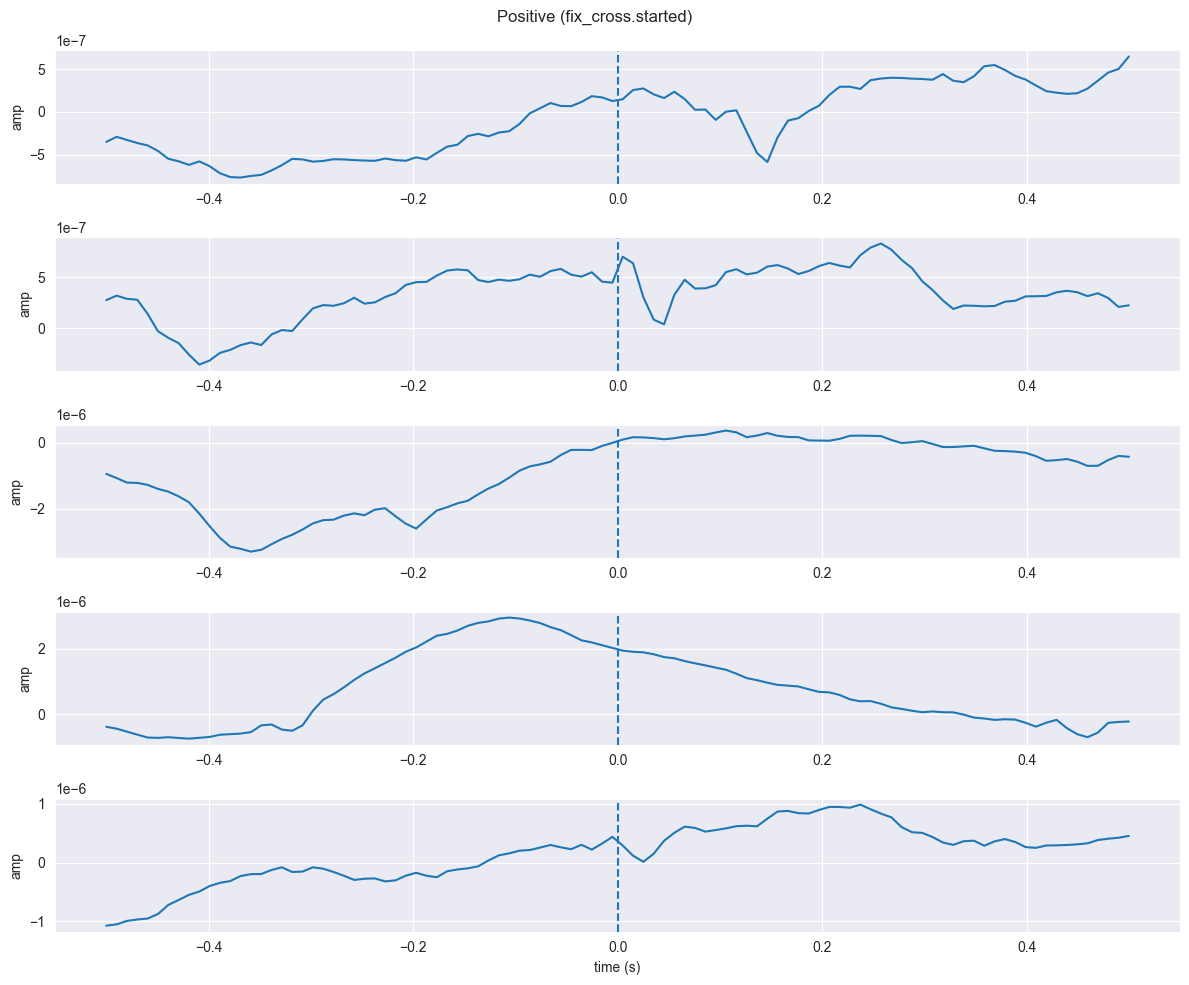

In [86]:
plot_windows(pos_windows, "Positive (fix_cross.started)")

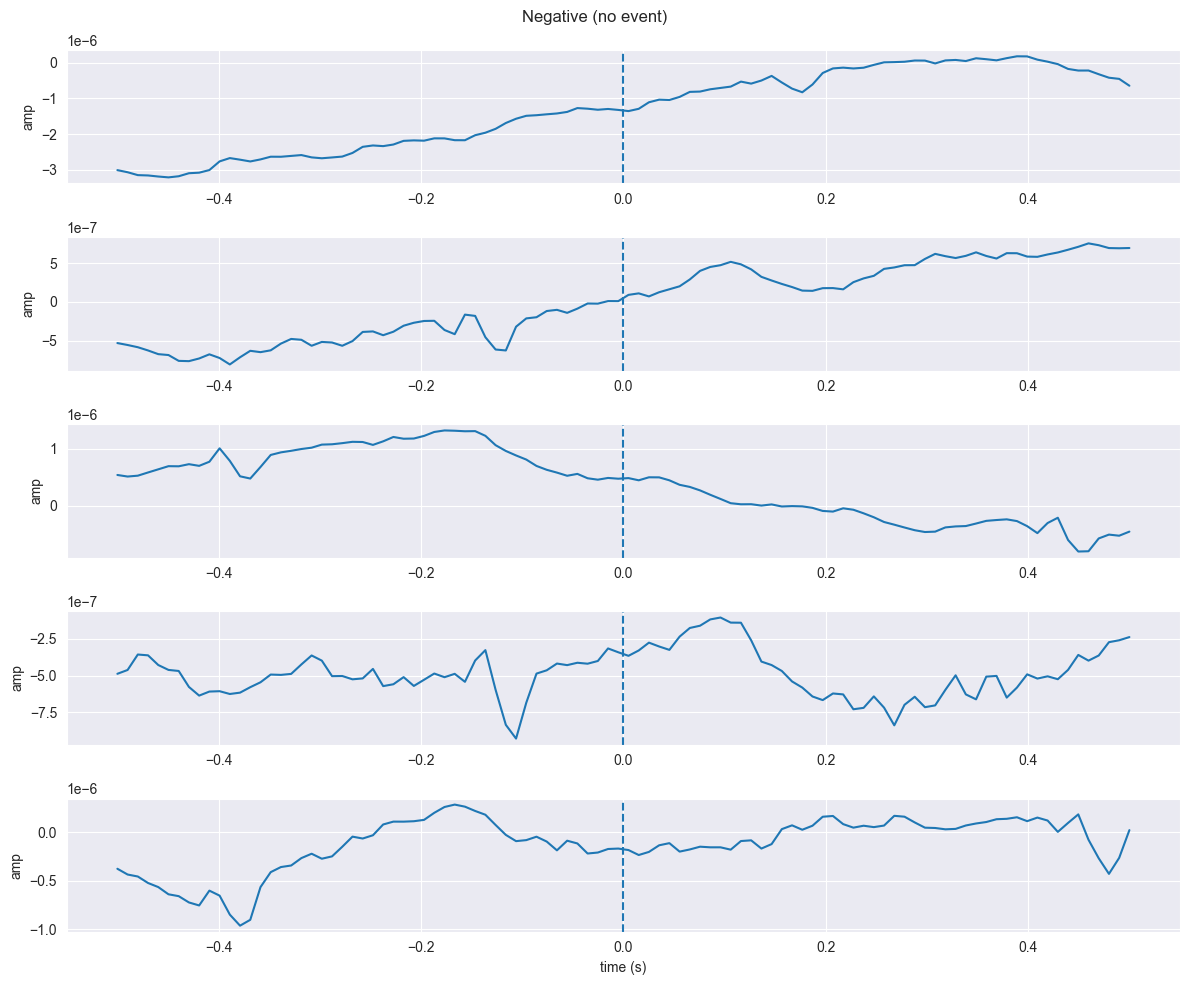

In [87]:
plot_windows(neg_windows, "Negative (no event)")

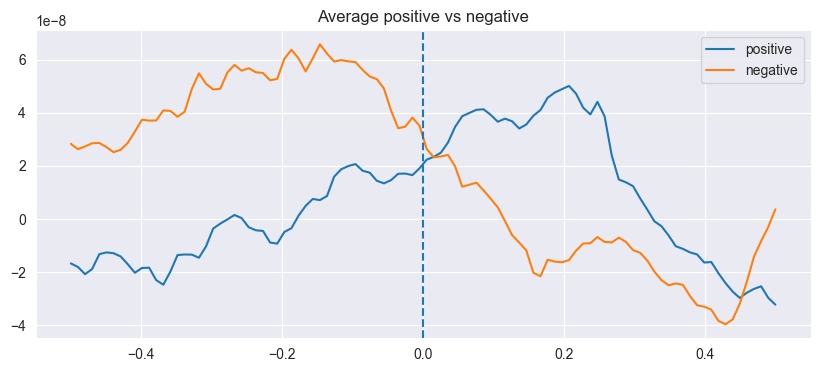

In [88]:
pos_mean = pos_windows.mean(axis=0).mean(axis=0)
neg_mean = neg_windows.mean(axis=0).mean(axis=0)

t = np.linspace(-win_sec/2, win_sec/2, len(pos_mean))

plt.figure(figsize=(10,4))
plt.plot(t, pos_mean, label="positive")
plt.plot(t, neg_mean, label="negative")
plt.axvline(0, linestyle="--")
plt.legend()
plt.title("Average positive vs negative")
plt.show()

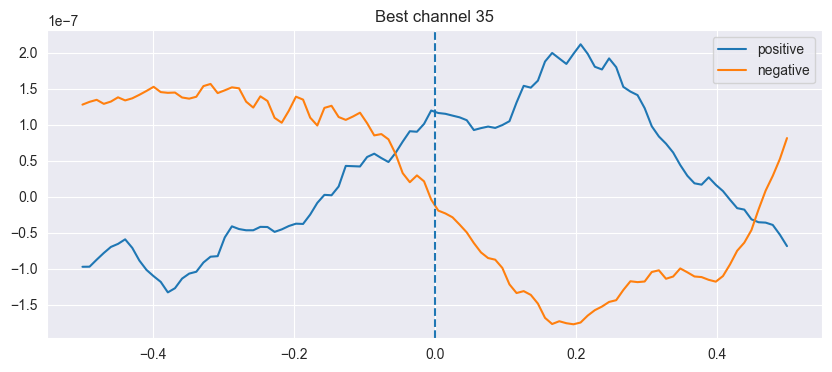

In [89]:
diff = pos_windows.mean(axis=0) - neg_windows.mean(axis=0)
ch = np.argmax(np.abs(diff).mean(axis=1))

plt.figure(figsize=(10,4))
plt.plot(t, pos_windows.mean(axis=0)[ch], label="positive")
plt.plot(t, neg_windows.mean(axis=0)[ch], label="negative")
plt.axvline(0, linestyle="--")
plt.legend()
plt.title(f"Best channel {ch}")
plt.show()

# train

In [83]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MEGEventCNN(X.shape[0]).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [84]:
epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, loss={total_loss/len(train_loader):.4f}")

Epoch 1, loss=0.7041
Epoch 2, loss=0.6968
Epoch 3, loss=0.6929
Epoch 4, loss=0.6881
Epoch 5, loss=0.6930
Epoch 6, loss=0.6897
Epoch 7, loss=0.6856
Epoch 8, loss=0.6810
Epoch 9, loss=0.6778
Epoch 10, loss=0.6774
Epoch 11, loss=0.6704
Epoch 12, loss=0.6668
Epoch 13, loss=0.6549
Epoch 14, loss=0.6195
Epoch 15, loss=0.6133


In [70]:
print("positive ratio:", y.mean())

positive ratio: 0.06354699174203697


In [90]:
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for xb, yb in train_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(yb.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

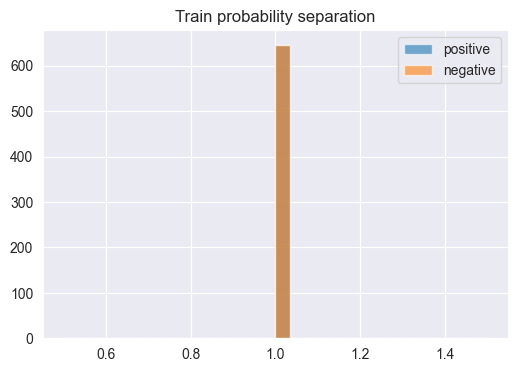

In [91]:
plt.figure(figsize=(6,4))
plt.hist(all_probs[all_labels==1], bins=30, alpha=0.6, label="positive")
plt.hist(all_probs[all_labels==0], bins=30, alpha=0.6, label="negative")
plt.legend()
plt.title("Train probability separation")
plt.show()

In [92]:
win = int(win_sec * sfreq)
half = win // 2

probs_full = np.zeros(X_norm.shape[1])

model.eval()
with torch.no_grad():
    for i in range(half, X_norm.shape[1]-half, 5):  # stride=5 samples
        window = X_norm[:, i-half:i+half]
        xb = torch.tensor(window[None], dtype=torch.float32).to(device)
        prob = torch.sigmoid(model(xb)).item()
        probs_full[i] = prob

In [93]:
from scipy.ndimage import gaussian_filter1d
probs_full = gaussian_filter1d(probs_full, sigma=2)

In [94]:
from scipy.signal import find_peaks

distance = int(0.5 * sfreq)
threshold = np.percentile(probs_full, 97)

peaks, _ = find_peaks(probs_full, height=threshold, distance=distance)

pred_samples = peaks
pred_times = pred_samples / sfreq

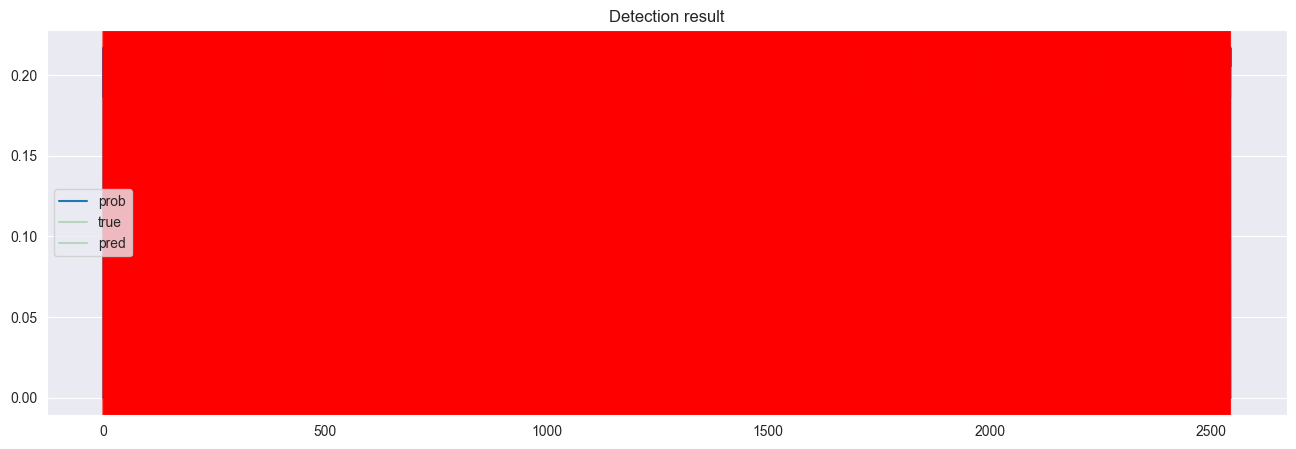

In [95]:
true_times = event_samples / sfreq
time = np.arange(len(probs_full)) / sfreq

plt.figure(figsize=(16,5))
plt.plot(time, probs_full, label="probability")

for t in true_times:
    plt.axvline(t, color="green", alpha=0.2)

for t in pred_times:
    plt.axvline(t, color="red", alpha=0.5)

plt.legend(["prob", "true", "pred"])
plt.title("Detection result")
plt.show()

# plot

## overall

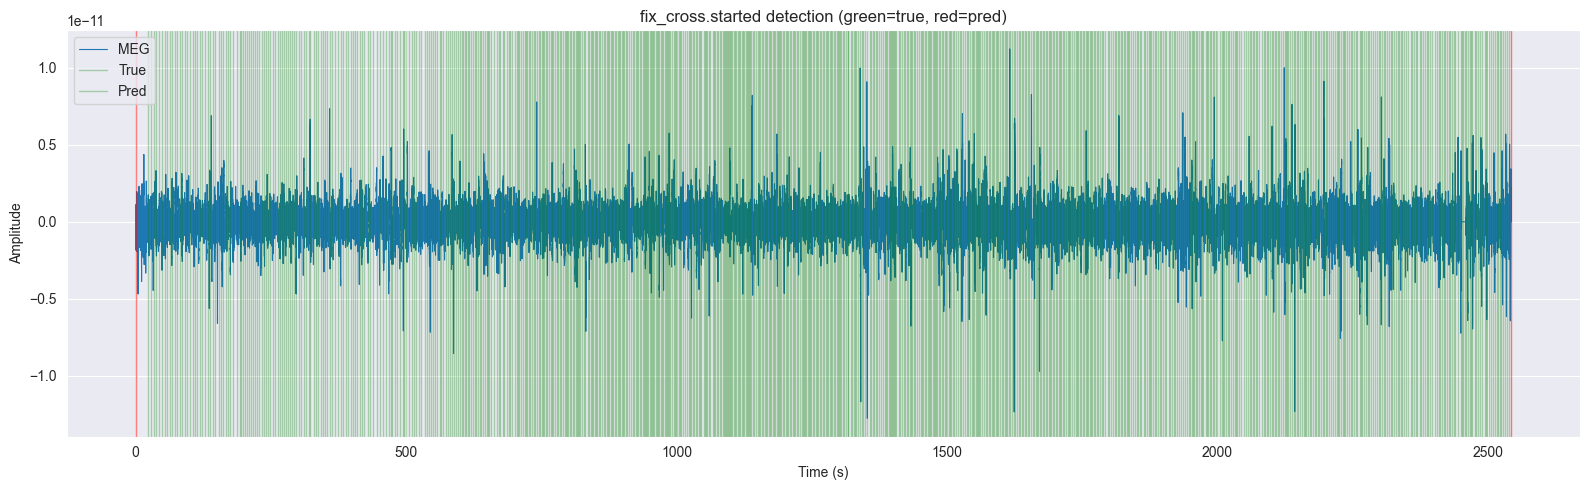

In [50]:
pred_times = pred_samples / sfreq
true_times = event_samples / sfreq

ch_idx = 0
signal = X[ch_idx]
time = np.arange(len(signal)) / sfreq

import matplotlib.pyplot as plt

plt.figure(figsize=(16,5))

plt.plot(time, signal, linewidth=0.8, label="MEG")

# true events
for t in true_times:
    plt.axvline(t, color="green", alpha=0.3, linewidth=1)

# predicted events
for t in pred_times:
    plt.axvline(t, color="red", alpha=0.5, linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("fix_cross.started detection (green=true, red=pred)")
plt.legend(["MEG", "True", "Pred"])
plt.tight_layout()
plt.show()

## small region

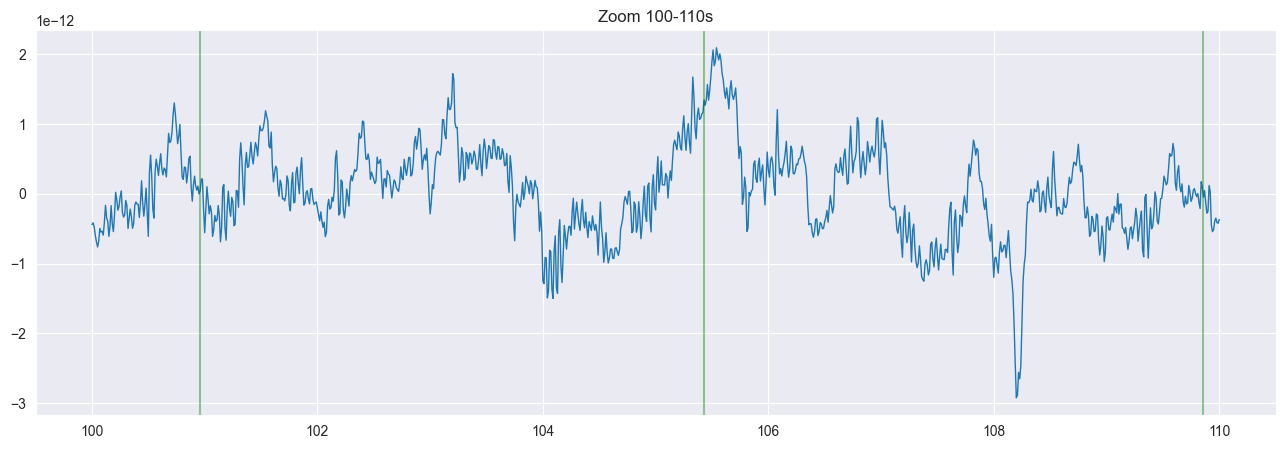

In [51]:
start = 100   # seconds
end = 110

mask = (time >= start) & (time <= end)

plt.figure(figsize=(16,5))
plt.plot(time[mask], signal[mask], linewidth=1)

for t in true_times:
    if start <= t <= end:
        plt.axvline(t, color="green", alpha=0.4)

for t in pred_times:
    if start <= t <= end:
        plt.axvline(t, color="red", alpha=0.6)

plt.title(f"Zoom {start}-{end}s")
plt.show()

## model prob

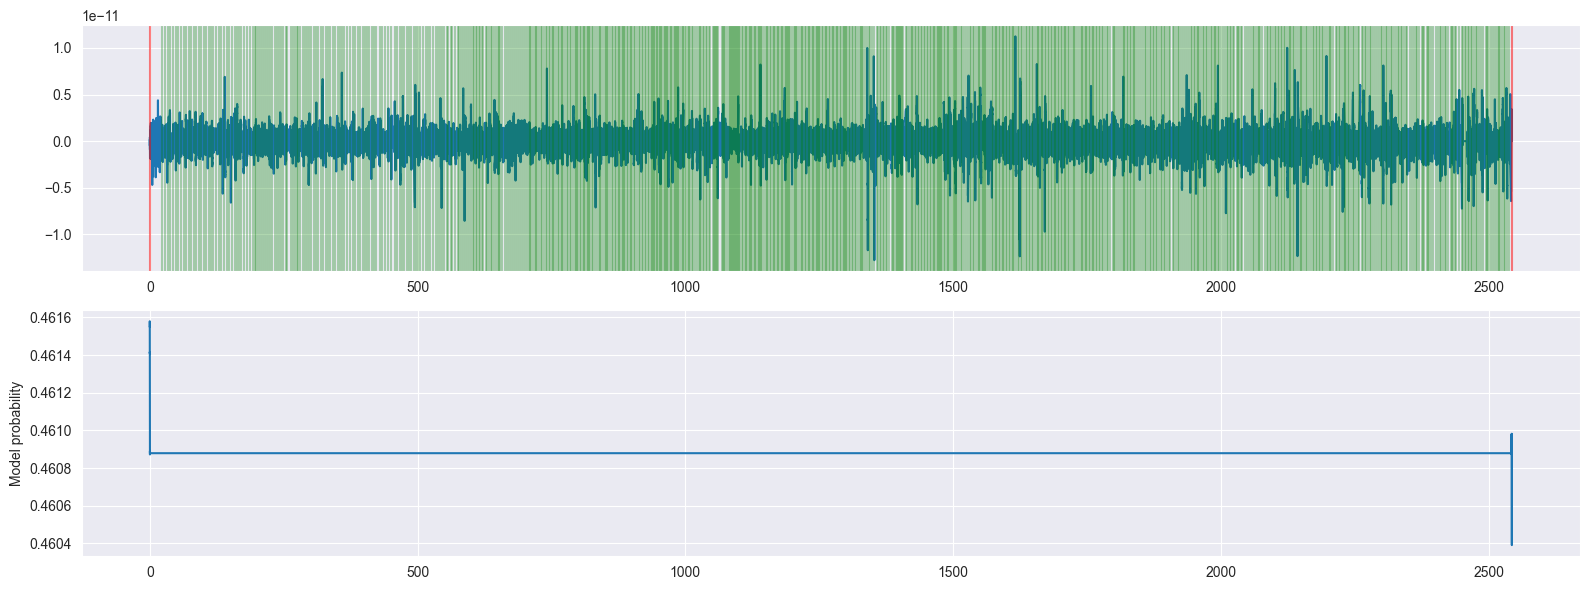

In [52]:
plt.figure(figsize=(16,6))

plt.subplot(2,1,1)
plt.plot(time, signal)

for t in true_times:
    plt.axvline(t, color="green", alpha=0.3)

for t in pred_times:
    plt.axvline(t, color="red", alpha=0.5)

plt.subplot(2,1,2)
plt.plot(time, probs)
plt.ylabel("Model probability")

plt.tight_layout()
plt.show()